In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,log_loss
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import os
os.chdir("/home/pgcp-ai/MachineLearning/Cases/Wisconsin/")

In [2]:
cancer = pd.read_csv("BreastCancer.csv",index_col='Code')
cancer

,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses,Class
Code,,,,,,,,,,
61634,5,4,3,1,2,2,2,3,1,Benign
63375,9,1,2,6,4,10,7,7,2,Malignant
76389,10,4,7,2,2,8,6,1,1,Malignant
95719,6,10,10,10,8,10,7,10,7,Malignant
128059,1,1,1,1,2,5,5,1,1,Benign
...,...,...,...,...,...,...,...,...,...,...
1369821,10,10,10,10,5,10,10,10,7,Malignant
1371026,5,10,10,10,4,10,5,6,3,Malignant
1371920,5,1,1,1,2,1,3,2,1,Benign


In [3]:
cancer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 699 entries, 61634 to 13454352
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Clump          699 non-null    int64 
 1   UniCell_Size   699 non-null    int64 
 2   Uni_CellShape  699 non-null    int64 
 3   MargAdh        699 non-null    int64 
 4   SEpith         699 non-null    int64 
 5   BareN          699 non-null    int64 
 6   BChromatin     699 non-null    int64 
 7   NoemN          699 non-null    int64 
 8   Mitoses        699 non-null    int64 
 9   Class          699 non-null    object
dtypes: int64(9), object(1)
memory usage: 60.1+ KB


In [4]:
cancer.isna().sum()

Clump            0
UniCell_Size     0
Uni_CellShape    0
MargAdh          0
SEpith           0
BareN            0
BChromatin       0
NoemN            0
Mitoses          0
Class            0
dtype: int64

In [7]:
le = LabelEncoder()

In [8]:
cancer["Class"] = le.fit_transform(cancer["Class"])

In [9]:
X,y = cancer.drop("Class", axis = 1), cancer["Class"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state = 26, stratify = y)

In [11]:
features = [2,3,4,5,6,7]
scores = []
for f in tqdm(features):
    for n in [25,50,75,100,125]:
        rf = RandomForestClassifier(max_features=f,n_estimators=n,random_state=26)
        rf.fit(X_train,y_train)
        y_pred = rf.predict(X_test)
        y_pred_prob = rf.predict_proba(X_test)
        scores.append([f,n,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores,columns=["No. of Features","No. of Estimators","Log Loss","Accuracy"])
df_scores.sort_values("Log Loss")

100%|█████████████████████████████████████████████| 6/6 [00:03<00:00,  1.59it/s]


,No. of Features,No. of Estimators,Log Loss,Accuracy
20,6,25,0.090337,0.957143
22,6,75,0.091812,0.961905
21,6,50,0.092632,0.961905
1,2,50,0.092803,0.966667
0,2,25,0.093055,0.966667
2,2,75,0.094992,0.966667
24,6,125,0.095253,0.966667
23,6,100,0.095366,0.961905
12,4,75,0.095764,0.957143
3,2,100,0.096179,0.966667


In [12]:
bm = RandomForestClassifier(max_features=6,random_state=26,n_estimators=25)
bm.fit(X,y)

RandomForestClassifier(max_features=6, n_estimators=25, random_state=26)

In [13]:
bm.feature_importances_

array([0.0555875 , 0.48146393, 0.19882089, 0.02220853, 0.01621914,
       0.12322675, 0.06158903, 0.03486333, 0.0060209 ])

In [25]:
df = pd.DataFrame({"Features":X.columns,"Importances":bm.feature_importances_})
df = df.sort_values('Importances',ascending=False)

<Axes: xlabel='Importances', ylabel='Features'>

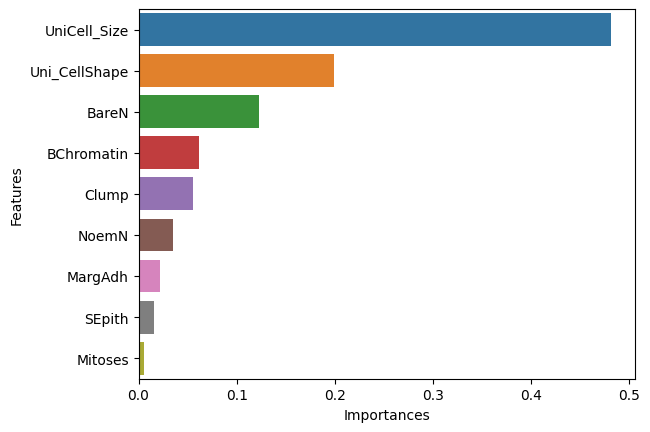

In [26]:
sns.barplot(data=df,y='Features',x='Importances',hue='Features')